In [51]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

In [52]:
#locating the processed data
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

In [53]:
# Loading the cleaned datasets
branches_df = pd.read_csv(PROCESSED_DIR / "branches.csv")
products_df = pd.read_csv(PROCESSED_DIR / "products.csv")
employees_df = pd.read_csv(PROCESSED_DIR / "employees.csv")
customers_df = pd.read_csv(PROCESSED_DIR / "customers.csv")
transactions_df = pd.read_csv(PROCESSED_DIR / "transactions.csv")

In [54]:
employees_df["Hire_Date"] = pd.to_datetime(employees_df["Hire_Date"])

customers_df["Join_Date"] = pd.to_datetime(customers_df["Join_Date"])

transactions_df["Transaction_Date"] = pd.to_datetime(
    transactions_df["Transaction_Date"]
)

Converting dates to an appropriate data type given its a CSV file, which converts it to text.

In [55]:
total_revenue = transactions_df["Total_Amount"].sum()

total_transactions = len(transactions_df)

total_customers = customers_df["Customer_ID"].nunique()

average_transaction = transactions_df["Total_Amount"].mean()

print("=" * 50)
print("BREW & BEAN BUSINESS SUMMARY")
print("=" * 50)

print(f"Total Revenue: KES {total_revenue:,.0f}")
print(f"Total Transactions: {total_transactions:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Average Transaction Value: KES {average_transaction:.2f}")

BREW & BEAN BUSINESS SUMMARY
Total Revenue: KES 35,499,800
Total Transactions: 50,000
Total Customers: 500
Average Transaction Value: KES 710.00


In [56]:
sales_df = transactions_df.merge(
    products_df,
    on="Product_ID",
    how="left"
)
sales_df.head()

,Transaction_ID,Transaction_Date,Customer_ID,Branch_ID,Employee_ID,Product_ID,Quantity,Unit_Price,Total_Amount,Payment_Method,Product_Name,Category,Price_KES,Available_All_Year,Calories
0,T000001,2025-11-30,C00362,BR003,E0027,P006,2,400,800,Credit Card,Mocha,Coffee,400,True,240
1,T000002,2026-01-03,C00110,BR004,E0028,P004,3,380,1140,Credit Card,Latte,Coffee,380,True,210
2,T000003,2026-08-06,C00269,BR003,E0024,P012,1,450,450,Cash,Cheesecake,Dessert,450,True,510
3,T000004,2024-10-31,C00409,BR002,E0013,P008,1,330,330,Debit Card,Chai Latte,Non-Coffee,330,True,250
4,T000005,2024-11-18,C00442,BR003,E0027,P006,3,400,1200,Cash,Mocha,Coffee,400,True,240


In [57]:
product_sales = (
    sales_df
    .groupby("Product_Name")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

product_sales

Product_Name
Chicken Sandwich       4552350
Cheesecake             3843900
Vanilla Latte          3537240
Mocha                  3264800
Latte                  3149820
Cappuccino             2910950
Hot Chocolate          2838660
Chai Latte             2720190
Chocolate Croissant    2500200
Blueberry Muffin       2313920
Americano              2038250
Espresso               1829520
Name: Total_Amount, dtype: int64

Did Chicken Sandwich make the most money because:

it sold the most units?

or

it has the highest price?

In [58]:
product_quantity = (
    sales_df
    .groupby("Product_Name")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

product_quantity

Product_Name
Cheesecake             8542
Vanilla Latte          8422
Hot Chocolate          8349
Chocolate Croissant    8334
Cappuccino             8317
Espresso               8316
Latte                  8289
Chicken Sandwich       8277
Blueberry Muffin       8264
Chai Latte             8243
Mocha                  8162
Americano              8153
Name: Quantity, dtype: int64

Chicken sandwich made the most simply because it costs *more*. 

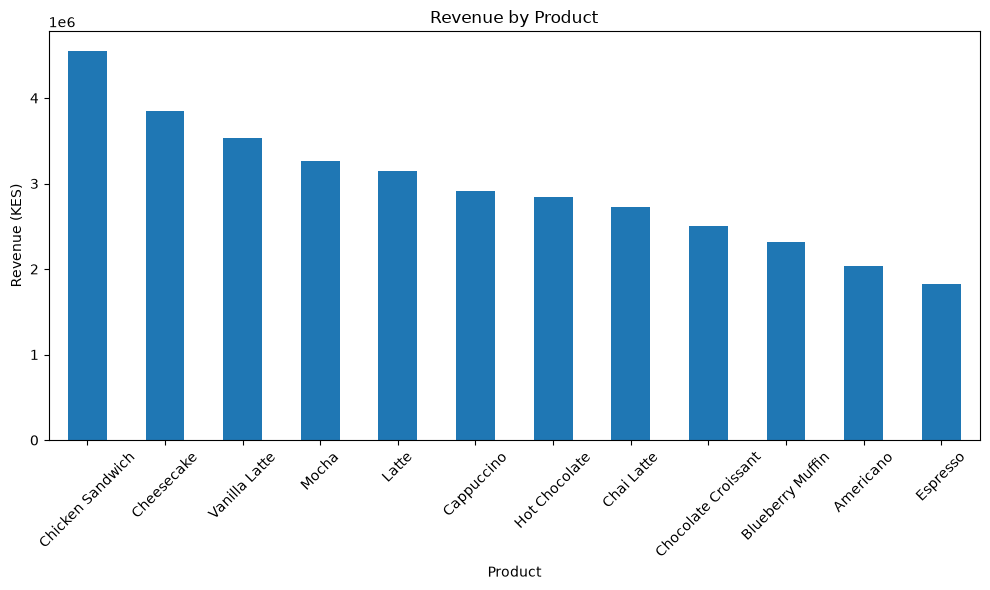

In [59]:
plt.figure(figsize=(10,6))

product_sales.plot(kind="bar")

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue (KES)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

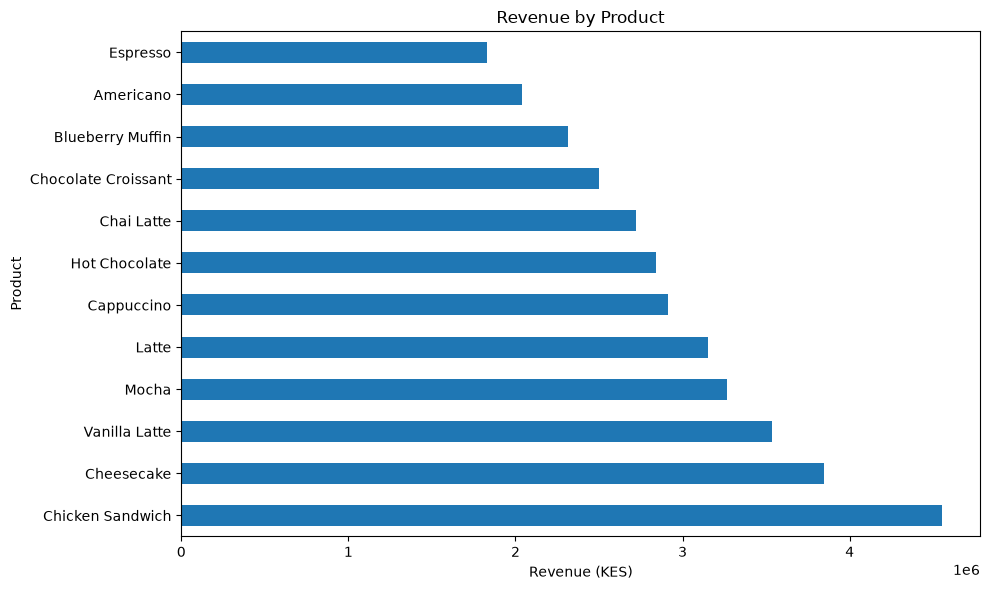

In [60]:
plt.figure(figsize=(10,6))

product_sales.plot(kind="barh")

plt.title("Revenue by Product")
plt.xlabel("Revenue (KES)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

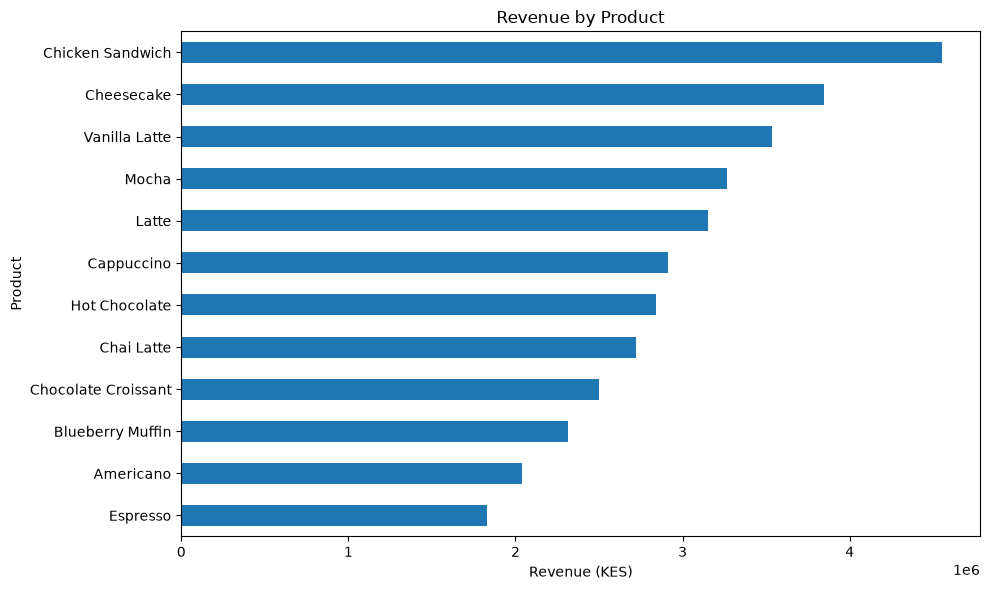

In [61]:
plt.figure(figsize=(10,6))

product_sales.sort_values().plot(kind="barh")

plt.title("Revenue by Product")
plt.xlabel("Revenue (KES)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

## Comparing Different Bar Chart Styles

The same data can be visualized in different ways.

- Vertical bar chart (`bar`)
- Horizontal bar chart (`barh`)
- Horizontal bar chart with sorted order for improved readability

For products with longer names, the sorted horizontal bar chart provides the clearest presentation.

In [62]:
branch_sales = (
    transactions_df
    .groupby("Branch_ID")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

branch_sales

Branch_ID
BR001    7139280
BR002    7112730
BR005    7104510
BR004    7082530
BR003    7060750
Name: Total_Amount, dtype: int64

In [63]:
branch_sales = (
    transactions_df
    .merge(branches_df, on="Branch_ID")
    .groupby("Branch_Name")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

branch_sales

Branch_Name
Westlands    7139280
Karen        7112730
Runda        7104510
CBD          7082530
Kilimani     7060750
Name: Total_Amount, dtype: int64

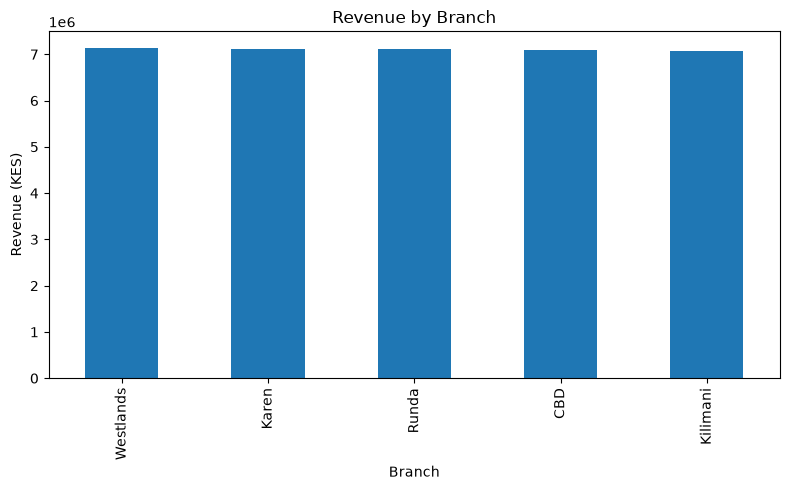

In [64]:
plt.figure(figsize=(8,5))

branch_sales.plot(kind="bar")

plt.title("Revenue by Branch")
plt.xlabel("Branch")
plt.ylabel("Revenue (KES)")

plt.tight_layout()
plt.show()

In [65]:
monthly_sales = (
    transactions_df
    .groupby(transactions_df["Transaction_Date"].dt.to_period("M"))["Total_Amount"]
    .sum()
)

monthly_sales

Transaction_Date
2024-08     297470
2024-09    1465470
2024-10    1488570
2024-11    1529830
2024-12    1582090
2025-01    1463610
2025-02    1297810
2025-03    1482870
2025-04    1438980
2025-05    1483600
2025-06    1465540
2025-07    1557650
2025-08    1521360
2025-09    1422530
2025-10    1458660
2025-11    1489100
2025-12    1476850
2026-01    1538890
2026-02    1422440
2026-03    1475930
2026-04    1451130
2026-05    1505010
2026-06    1450470
2026-07    1443140
2026-08    1290800
Freq: M, Name: Total_Amount, dtype: int64

'.dt.to_period("M")' tells pandas to ignore the individual days and group everything by month.

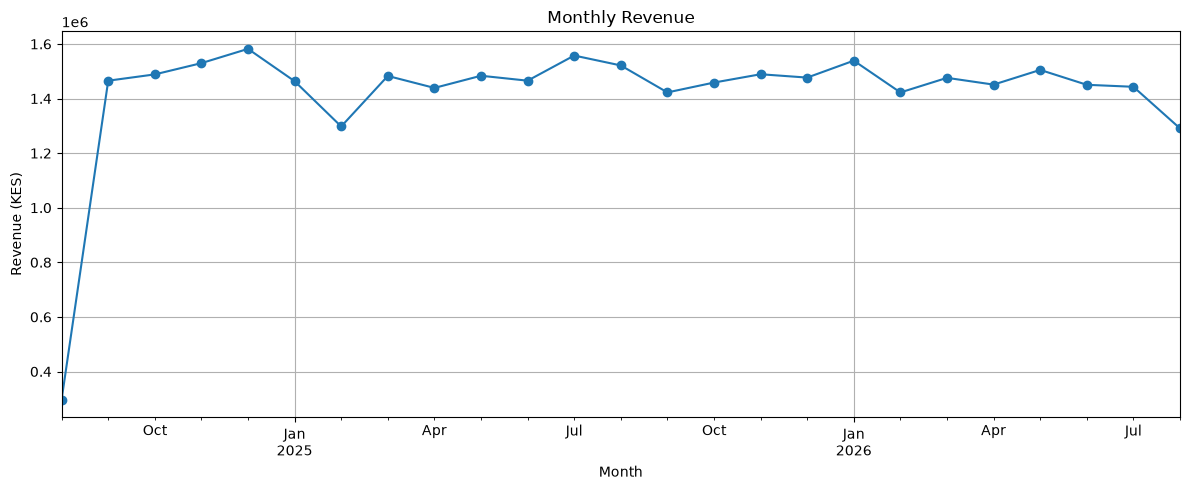

In [66]:
plt.figure(figsize=(12,5))

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (KES)")

plt.grid(True)

plt.tight_layout()
plt.show()

## Revenue by Category

In [67]:
category_sales = (
    sales_df
    .groupby("Category")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

Category
Coffee        16730580
Non-Coffee     5558850
Pastry         4814120
Food           4552350
Dessert        3843900
Name: Total_Amount, dtype: int64

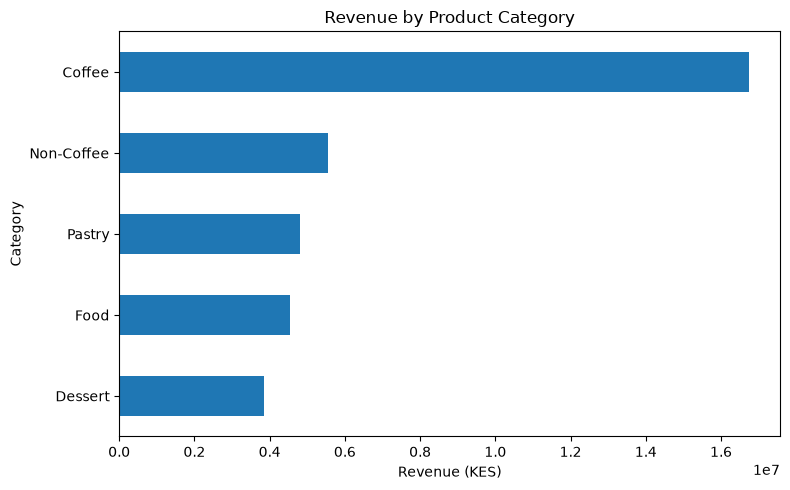

In [68]:
plt.figure(figsize=(8,5))

category_sales.sort_values().plot(kind="barh")

plt.title("Revenue by Product Category")
plt.ylabel("Category")
plt.xlabel("Revenue (KES)")

plt.tight_layout()
plt.show()

## Revenue by Product Category

### Objective
Determine which product categories generate the highest revenue for Brew & Bean and identify the café's primary sources of income.

### Business Insight
Coffee generated the highest revenue, contributing approximately **KES 16.7 million**, making it the café's strongest-performing product category. This suggests that coffee remains the core product and primary driver of business revenue.

Among the remaining categories, **Non-Coffee** beverages ranked second, followed by **Pastry**, **Food**, and **Dessert**. Although these categories generated lower revenue individually, they collectively contribute a significant portion of total sales and provide customers with a wider variety of products.

The results indicate that while Brew & Bean is primarily a coffee business, maintaining a diverse menu helps increase overall revenue and enhances the customer experience.

### Key Takeaway
**Coffee is the primary revenue driver, while complementary food and beverage categories provide valuable additional income and diversify the café's sales.**

## Payment Method Analysis

### Objective
Analyze customer payment preferences by identifying the most frequently used payment methods and the revenue generated by each method.

In [69]:
payment_count = (
    transactions_df["Payment_Method"]
    .value_counts()
)

payment_count

Payment_Method
Credit Card    12670
Cash           12567
M-Pesa         12392
Debit Card     12371
Name: count, dtype: int64

In [70]:
payment_revenue = (
    transactions_df
    .groupby("Payment_Method")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

payment_revenue

Payment_Method
Credit Card    9079230
Cash           8950400
Debit Card     8744620
M-Pesa         8725550
Name: Total_Amount, dtype: int64

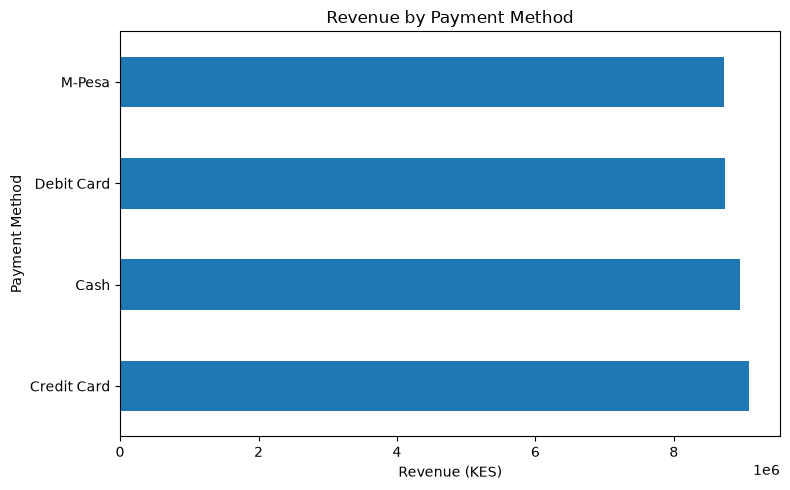

In [71]:
plt.figure(figsize=(8,5))

payment_revenue.plot(kind="barh")

plt.title("Revenue by Payment Method")
plt.xlabel("Revenue (KES)")
plt.ylabel("Payment Method")

plt.tight_layout()
plt.show()

### Business Insight

The analysis shows how customers prefer to pay for their purchases and the amount of revenue generated through each payment method. A relatively balanced distribution suggests that customers are comfortable using multiple payment options, while a dominant payment method may indicate changing customer preferences.

Understanding payment trends helps the business ensure that the most popular payment options remain reliable and readily available, improving customer convenience and overall service quality.

### Key Takeaway

**Maintaining multiple payment options supports customer convenience, while monitoring payment trends helps the business adapt to changing customer preferences.**

## Customer Type Analysis

### Objective
Analyze revenue generated by each customer type to identify the most valuable customer segment.

In [72]:
sales_customers = sales_df.merge(
    customers_df,
    on="Customer_ID",
    how="left"
)

sales_customers.head()

,Transaction_ID,Transaction_Date,Customer_ID,Branch_ID,Employee_ID,Product_ID,Quantity,Unit_Price,Total_Amount,Payment_Method,...,Price_KES,Available_All_Year,Calories,Customer_Name,Age,Gender,Customer_Type,Preferred_Branch,Loyalty_Member,Join_Date
0,T000001,2025-11-30,C00362,BR003,E0027,P006,2,400,800,Credit Card,...,400,True,240,Cheryl Wright,58,Female,Professional,Kilimani,Yes,2026-05-25
1,T000002,2026-01-03,C00110,BR004,E0028,P004,3,380,1140,Credit Card,...,380,True,210,Cody Cox,19,Female,Professional,Kilimani,No,2025-11-21
2,T000003,2026-08-06,C00269,BR003,E0024,P012,1,450,450,Cash,...,450,True,510,Kimberly Acosta,33,Female,Tourist,Runda,Yes,2026-02-20
3,T000004,2024-10-31,C00409,BR002,E0013,P008,1,330,330,Debit Card,...,330,True,250,Christopher Taylor,20,Male,Regular,CBD,No,2025-03-24
4,T000005,2024-11-18,C00442,BR003,E0027,P006,3,400,1200,Cash,...,400,True,240,Justin Walker,32,Male,Professional,CBD,Yes,2022-11-22


In [73]:
customer_type_revenue = (
    sales_customers
    .groupby("Customer_Type")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

customer_type_revenue

Customer_Type
Professional     11664410
Student           9950860
Remote Worker     6120690
Regular           6080630
Tourist           1683210
Name: Total_Amount, dtype: int64

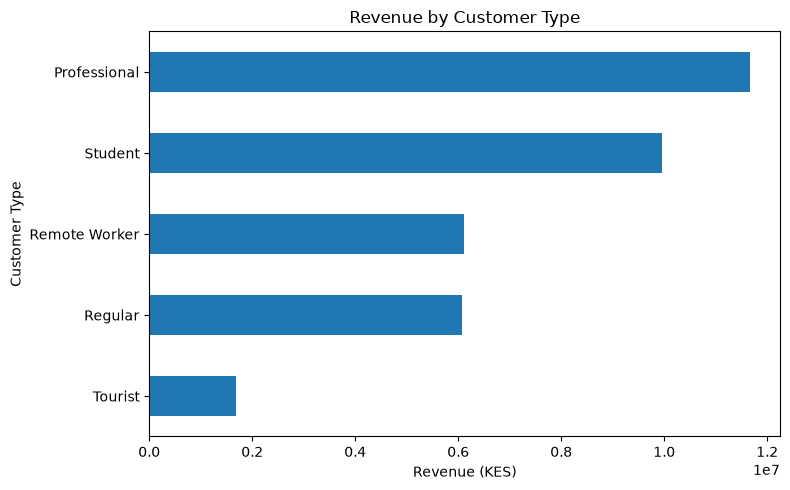

In [74]:
plt.figure(figsize=(8,5))

customer_type_revenue.sort_values().plot(kind="barh")

plt.title("Revenue by Customer Type")
plt.ylabel("Customer Type")
plt.xlabel("Revenue (KES)")

plt.tight_layout()
plt.show()

### Business Insight

The analysis shows that customer revenue varies across different customer segments, with one group contributing the highest share of sales.

### Key Takeaway

**Understanding customer segments helps the business identify and better serve its highest-value customers.**

### 📌 Insight

Professional customers generated the highest revenue, followed by students. Tourist customers contributed the least revenue during the period.

In [76]:
# Merge customer information into the sales data
sales_loyalty = sales_df.merge(
    customers_df[["Customer_ID", "Loyalty_Member"]],
    on="Customer_ID",
    how="left"
)

sales_loyalty.head()

,Transaction_ID,Transaction_Date,Customer_ID,Branch_ID,Employee_ID,Product_ID,Quantity,Unit_Price,Total_Amount,Payment_Method,Product_Name,Category,Price_KES,Available_All_Year,Calories,Loyalty_Member
0,T000001,2025-11-30,C00362,BR003,E0027,P006,2,400,800,Credit Card,Mocha,Coffee,400,True,240,Yes
1,T000002,2026-01-03,C00110,BR004,E0028,P004,3,380,1140,Credit Card,Latte,Coffee,380,True,210,No
2,T000003,2026-08-06,C00269,BR003,E0024,P012,1,450,450,Cash,Cheesecake,Dessert,450,True,510,Yes
3,T000004,2024-10-31,C00409,BR002,E0013,P008,1,330,330,Debit Card,Chai Latte,Non-Coffee,330,True,250,No
4,T000005,2024-11-18,C00442,BR003,E0027,P006,3,400,1200,Cash,Mocha,Coffee,400,True,240,Yes


In [77]:
# Revenue by Loyalty Member
loyalty_revenue = (
    sales_loyalty.groupby("Loyalty_Member")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

print(loyalty_revenue)

Loyalty_Member
Yes    22584200
No     12915600
Name: Total_Amount, dtype: int64


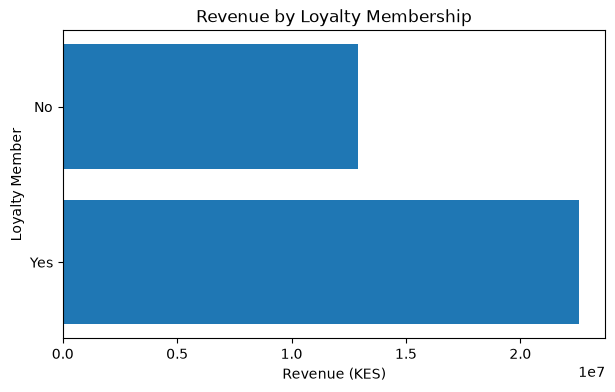

In [78]:
plt.figure(figsize=(7,4))

plt.barh(
    loyalty_revenue.index,
    loyalty_revenue.values
)

plt.title("Revenue by Loyalty Membership")
plt.xlabel("Revenue (KES)")
plt.ylabel("Loyalty Member")

plt.show()

## Loyalty Member Analysis

### Objective
Compare revenue generated by loyalty members and non-loyalty members to evaluate the impact of the loyalty program.

### Business Insight
Loyalty members generated higher revenue than non-members, suggesting that the loyalty program contributes positively to overall sales.

### Key Takeaway
**The loyalty program appears to encourage higher customer spending and supports business growth.**

In [82]:
branches_df.to_csv("../data/processed/branches_clean.csv", index=False)
products_df.to_csv("../data/processed/products_clean.csv", index=False)
employees_df.to_csv("../data/processed/employees_clean.csv", index=False)
customers_df.to_csv("../data/processed/customers_clean.csv", index=False)
transactions_df.to_csv("../data/processed/transactions_clean.csv", index=False)

print("✅ Cleaned datasets saved successfully!")

✅ Cleaned datasets saved successfully!


# Project Summary

## Overview

This notebook explored the Brew & Bean Café dataset using Python to understand sales performance, customer behavior, and business trends.

## Key Activities

- Loaded and inspected multiple datasets
- Verified data quality by checking data types, duplicates, missing values, and unique identifiers
- Performed exploratory data analysis (EDA)
- Created visualizations to summarize business performance
- Generated business insights from the analysis
- Saved cleaned datasets for dashboard development in Power BI

## Next Step

The cleaned datasets will be used to build an interactive Power BI dashboard for business reporting and visualization.